### Guest voice, review aspects
* keyword lexicons for the aspects guests write about in Lisbon Airbnb reviews
* mention share and negative share per aspect and per neighbourhood
* exports the aspect table for the market page

In [1]:
import os
import re
import json
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
REVIEWS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "airbnb_reviews_sample.parquet")
LISTINGS_PATH = os.path.join(ROOT_DIR, "data", "parquet", "airbnb_listings.parquet")
MODELS_DIR = os.path.join(ROOT_DIR, "data", "models")
aspects = {
    "noise": ["noise", "noisy", "loud", "quiet", "soundproof", "earplugs"],
    "cleanliness": ["clean", "dirty", "spotless", "dust", "smell", "mold", "mould", "stain"],
    "check in": ["check in", "check-in", "checkin", "keys", "lockbox", "self check", "arrival"],
    "host": ["host", "responsive", "helpful", "friendly", "communication", "welcoming"],
    "location": ["location", "central", "metro", "walk", "close to", "neighbourhood", "neighborhood"],
    "comfort": ["bed", "mattress", "pillow", "comfortable", "uncomfortable", "sofa"],
    "bathroom": ["bathroom", "shower", "water pressure", "hot water", "toilet"],
    "stairs": ["stairs", "elevator", "lift", "floor", "steep", "hill"],
    "wifi": ["wifi", "wi-fi", "internet", "connection"],
    "value": ["value", "price", "expensive", "cheap", "worth"],
    "temperature": ["hot", "cold", "heating", "air conditioning", "aircon", "fan", "heater"],
    "view": ["view", "balcony", "terrace", "rooftop", "river"],
}
positive = ["great", "perfect", "amazing", "lovely", "clean", "excellent", "wonderful", "helpful", "friendly", "beautiful", "comfortable", "recommend", "fantastic", "spotless", "quiet", "convenient", "cozy", "easy", "good", "nice", "best"]
negative = ["dirty", "noise", "noisy", "loud", "broken", "smell", "cold", "small", "problem", "issue", "uncomfortable", "rude", "difficult", "disappointed", "bad", "poor", "stairs", "hot", "mold", "mould", "bugs", "late", "cancel", "not", "no", "never", "unfortunately", "worst", "terrible"]

In [2]:
# load english looking reviews and strip html
def load_reviews(path):
    frame = pd.read_parquet(path)
    frame["text"] = frame["comments"].str.replace(r"<br\s*/?>", " ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip().str.lower()
    english = frame["text"].str.count(r"\b(?:the|and|was|were|very|our|we|it|with|for)\b") >= 3
    foreign = frame["text"].str.contains(r"\b(?:und|ist|sehr|het|een|très|molto|muito|estaba|nous)\b", regex=True)
    frame = frame[english & ~foreign & (frame["text"].str.len() >= 40)].reset_index(drop=True)
    return frame

In [3]:
# sentences that mention an aspect, with a local sentiment score from the lexicons
def aspect_mentions(frame):
    pos_re = re.compile(r"\b(" + "|".join(positive) + r")\b")
    neg_re = re.compile(r"\b(" + "|".join(negative) + r")\b")
    rows = []
    for review_id, listing_id, text in zip(frame["review_id"], frame["listing_id"], frame["text"]):
        for sentence in re.split(r"[.!?;]", text):
            for aspect, words in aspects.items():
                if any(w in sentence for w in words):
                    p = len(pos_re.findall(sentence))
                    n = len(neg_re.findall(sentence))
                    rows.append({"review_id": review_id, "listing_id": listing_id, "aspect": aspect, "score": (p - n) / max(p + n, 1)})
    return pd.DataFrame(rows)

In [4]:
# aspect table with mention share and negative share
def aspect_table(mentions, n_reviews):
    grp = mentions.groupby("aspect").agg(mentions=("review_id", "nunique"), negative_share=("score", lambda s: float((s < 0).mean())))
    grp["mention_share"] = grp["mentions"] / n_reviews
    return grp.sort_values("negative_share", ascending=False).round(3)

In [5]:
# negative share of the noise and cleanliness aspects per neighbourhood
def aspect_by_neighbourhood(mentions, listings_path, min_mentions=80):
    listings = pd.read_parquet(listings_path)[["id", "neighbourhood_cleansed"]]
    listings["id"] = pd.to_numeric(listings["id"], errors="coerce")
    merged = mentions.merge(listings, left_on="listing_id", right_on="id", how="inner")
    grp = merged.groupby(["neighbourhood_cleansed", "aspect"]).agg(mentions=("review_id", "nunique"), negative_share=("score", lambda s: float((s < 0).mean()))).reset_index()
    return grp[grp["mentions"] >= min_mentions].round(3)

In [6]:
# bar chart of negative share per aspect
def plot_aspects(table):
    plt.figure(figsize=(7, 4))
    plt.barh(table.index[::-1], table["negative_share"][::-1], color="red")
    plt.xlabel("share of mentions with negative wording")
    plt.title("Negative share by aspect")
    plt.show()

In [7]:
# save the aspect tables
def export(table, by_nb, n_reviews, from_date):
    os.makedirs(MODELS_DIR, exist_ok=True)
    out = {"reviews": int(n_reviews), "from_date": str(from_date), "aspects": table.reset_index().to_dict("records"), "by_neighbourhood": by_nb.to_dict("records"), "generated_at": datetime.datetime.now(datetime.timezone.utc).isoformat()}
    with open(os.path.join(MODELS_DIR, "review_aspects.json"), "w") as f:
        json.dump(out, f, indent=2)
    print("saved " + os.path.join(MODELS_DIR, "review_aspects.json"))

english reviews 31323


             mentions  negative_share  mention_share
aspect                                              
stairs           4427           0.429          0.141
noise            5993           0.376          0.191
bathroom         3865           0.334          0.123
temperature      4933           0.241          0.157
wifi              630           0.240          0.020
value            2075           0.146          0.066
comfort          9462           0.113          0.302
check in         4471           0.103          0.143
cleanliness     10842           0.102          0.346
view             5405           0.075          0.173
location        20627           0.049          0.659
host            16336           0.046          0.522


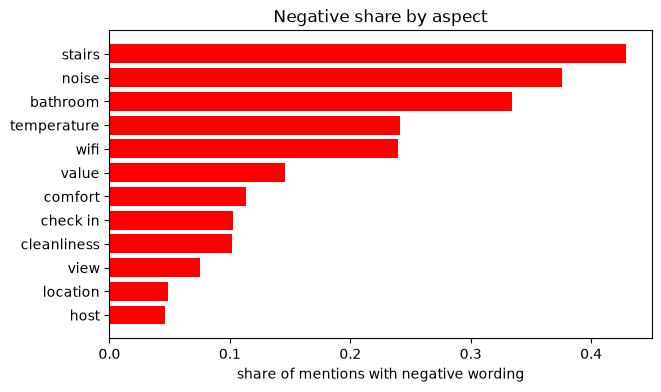

In [8]:
reviews = load_reviews(REVIEWS_PATH)
print("english reviews " + str(len(reviews)))
mentions = aspect_mentions(reviews)
table = aspect_table(mentions, len(reviews))
print(table.to_string())
plot_aspects(table)

In [9]:
by_nb = aspect_by_neighbourhood(mentions, LISTINGS_PATH)
print(by_nb[by_nb["aspect"] == "noise"].sort_values("negative_share", ascending=False).head(10).to_string(index=False))
export(table, by_nb, len(reviews), reviews["date"].min())

neighbourhood_cleansed aspect  mentions  negative_share
           Misericrdia  noise      1432           0.502
     Santa Maria Maior  noise      1478           0.430
               Arroios  noise       370           0.377
        Avenidas Novas  noise       110           0.362
      Campo de Ourique  noise        91           0.330
            So Vicente  noise       405           0.292
        Penha de Frana  noise       118           0.290
          Santo Antnio  noise       459           0.285
     Cascais e Estoril  noise       270           0.253
               Estrela  noise       287           0.245
saved /srv/data/models/review_aspects.json
